# IR ALÉM 2 – Inteligência Artificial em séries temporais de saúde

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
# Configuração de reprodutibilidade
np.random.seed(42)

def generate_ecg(heart_rate, duration=1.0, fs=500):
    """Gera um sinal sintético simples de ECG."""
    t = np.linspace(0, duration, int(fs * duration))
    # Simula o complexo QRS como um pico agudo
    signal = np.zeros_like(t)
    peaks = np.arange(0, duration, 60/heart_rate)
    for p in peaks:
        idx = np.argmin(np.abs(t - p))
        signal[idx:idx+10] = 1.0 # Pulso simplificado
    
    # Adiciona ruído biológico
    signal += np.random.normal(0, 0.1, size=len(t))
    return signal

# Criando o Dataset (50 normais, 50 arritmias)
data = []
labels = []

for _ in range(50):
    data.append(generate_ecg(heart_rate=70)) # Normal
    labels.append(0)
    data.append(generate_ecg(heart_rate=120)) # Taquicardia
    labels.append(1)

X = np.array(data)
y = np.array(labels)

print(f"Dataset criado: {X.shape[0]} amostras de {X.shape[1]} pontos cada.")

Dataset criado: 100 amostras de 500 pontos cada.


In [12]:
# Extração de Features Simples
X_features = np.column_stack([
    np.mean(X, axis=1), 
    np.std(X, axis=1),
    np.max(X, axis=1)
])

X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.2)

# Treinamento
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Avaliação
lr_acc = lr_model.score(X_test, y_test)
print(f"Acurácia Regressão Logística: {lr_acc * 100:.2f}%")

Acurácia Regressão Logística: 45.00%


In [13]:
def lif_neuron(signal, threshold=0.8, tau=20.0):
    v = 0.0
    spikes = 0
    v_history = []
    
    for x in signal:
        # Equação de membrana: dv/dt = (-v + sinal) / tau
        v += (-v + x) / tau
        if v >= threshold:
            spikes += 1
            v = 0.0 # Reset
        v_history.append(v)
    return spikes

# Simulação para o dataset
lif_spikes = np.array([lif_neuron(s) for s in X])

# Classificação simples baseada em um threshold de spikes
# (Se disparar mais que a média, é Arritmia)
spike_threshold = np.mean(lif_spikes)
y_pred_lif = (lif_spikes > spike_threshold).astype(int)

# Avaliação LIF
lif_acc = np.mean(y_pred_lif == y)
print(f"Acurácia Modelo LIF: {lif_acc * 100:.2f}%")

Acurácia Modelo LIF: 50.00%


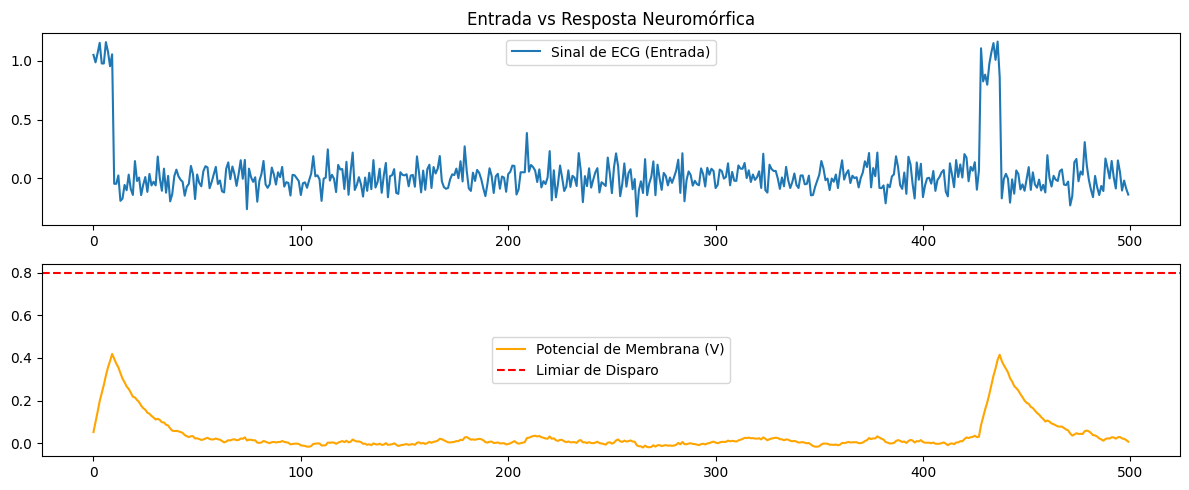

In [14]:
sample_idx = 0 # Um sinal normal
sample_signal = X[sample_idx]
v = []
v_curr = 0
for x in sample_signal:
    v_curr += (-v_curr + x) / 20.0
    v.append(v_curr)

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(sample_signal, label="Sinal de ECG (Entrada)")
plt.title("Entrada vs Resposta Neuromórfica")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(v, color='orange', label="Potencial de Membrana (V)")
plt.axhline(y=0.8, color='r', linestyle='--', label="Limiar de Disparo")
plt.legend()
plt.tight_layout()
plt.show()